In [3]:
!pip install nltk scikit-learn xgboost tensorflow tensorflow-hub transformers torch

In [4]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [7]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub(r'<[^>]*>', '', text)
    text = text.strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()

    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

In [8]:
df = pd.read_csv("IMDB Dataset.csv")

# shuffle
df = df.sample(frac=1).reset_index(drop=True)

print("Preprocessing...")
df['review'] = df['review'].apply(preprocess_text)

Preprocessing...


In [9]:
X = df['review']
y = df['sentiment']

label_encode = LabelEncoder()
Y = label_encode.fit_transform(y)

xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(xtrain)
X_test_tfidf = tfidf.transform(xtest)

In [11]:
models = {
    "LinearSVM": LinearSVC(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": MultinomialNB(),
    "XGBoost": XGBClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100)
}

In [12]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"\n===== {model.__class__.__name__} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [13]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, ytrain)
    evaluate_model(model, X_test_tfidf, ytest)


Training LinearSVM...

===== LinearSVC =====
Accuracy: 0.879
Precision: 0.8765625
Recall: 0.8859060402684564
F1 Score: 0.8812095032397408

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88      4934
           1       0.88      0.89      0.88      5066

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Confusion Matrix:
 [[4302  632]
 [ 578 4488]]

Training LogisticRegression...

===== LogisticRegression =====
Accuracy: 0.8877
Precision: 0.8836349484335474
Recall: 0.8963679431504146
F1 Score: 0.8899559039686428

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89      4934
           1       0.88      0.90      0.89      5066

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000

In [14]:
import tensorflow_hub as hub
import tensorflow as tf

print("Loading USE model...")
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

Loading USE model...


In [15]:
def encode_data(data, batch_size=512):
    embeddings = []

    for i in range(0, len(data), batch_size):
        batch = data[i:i+batch_size]
        emb = embed(batch)
        embeddings.extend(emb.numpy())

    return np.array(embeddings)

print("Encoding training data...")
X_train_use = encode_data(xtrain)

print("Encoding test data...")
X_test_use = encode_data(xtest)

Encoding training data...
Encoding test data...


In [17]:
for name, model in models.items():
    if name == "NaiveBayes":
        continue   # skip for USE

    print(f"\nTraining {name} with USE...")
    model.fit(X_train_use, ytrain)
    evaluate_model(model, X_test_use, ytest)


Training LinearSVM with USE...

===== LinearSVC =====
Accuracy: 0.8308
Precision: 0.8341917591125199
Recall: 0.8312277931306751
F1 Score: 0.832707138619735

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      4934
           1       0.83      0.83      0.83      5066

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000

Confusion Matrix:
 [[4097  837]
 [ 855 4211]]

Training LogisticRegression with USE...

===== LogisticRegression =====
Accuracy: 0.8304
Precision: 0.835791151853328
Recall: 0.8278720884326886
F1 Score: 0.8318127727092424

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.83      4934
           1       0.84      0.83      0.83      5066

    accuracy                           0.83     10000
   macro avg       0.83    

In [18]:
import numpy as np

X_train_combined = np.concatenate((X_train_tfidf.toarray(), X_train_use), axis=1)
X_test_combined = np.concatenate((X_test_tfidf.toarray(), X_test_use), axis=1)

In [19]:
for name, model in models.items():
    if name == "NaiveBayes":
        continue

    print(f"\nTraining {name} with TF-IDF + USE...")
    model.fit(X_train_combined, ytrain)
    evaluate_model(model, X_test_combined, ytest)


Training LinearSVM with TF-IDF + USE...

===== LinearSVC =====
Accuracy: 0.881
Precision: 0.881496062992126
Recall: 0.8839320963284643
F1 Score: 0.8827123989749655

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88      4934
           1       0.88      0.88      0.88      5066

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Confusion Matrix:
 [[4332  602]
 [ 588 4478]]

Training LogisticRegression with TF-IDF + USE...

===== LogisticRegression =====
Accuracy: 0.8858
Precision: 0.8836527180289402
Recall: 0.8920252664824319
F1 Score: 0.887819253438114

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88      4934
           1       0.88      0.89      0.89      5066

    accuracy                           0.89     10000
   macro a

In [20]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW

In [21]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [22]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [23]:
# Reduce size for faster training
xtrain_small = xtrain[:10000]
ytrain_small = ytrain[:10000]

xtest_small = xtest[:2000]
ytest_small = ytest[:2000]

train_dataset = IMDBDataset(xtrain_small, ytrain_small)
test_dataset = IMDBDataset(xtest_small, ytest_small)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [25]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [26]:
from tqdm import tqdm

model.train()

for epoch in range(1):  # keep 1 for speed
    loop = tqdm(train_loader, leave=True)

    for batch in loop:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

Epoch 0: 100%|██████████| 1250/1250 [3:57:02<00:00, 11.38s/it, loss=0.306]


In [27]:
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predictions = torch.argmax(logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("BERT Results:")
print("Accuracy:", accuracy_score(true_labels, preds))
print("Precision:", precision_score(true_labels, preds))
print("Recall:", recall_score(true_labels, preds))
print("F1 Score:", f1_score(true_labels, preds))

BERT Results:
Accuracy: 0.863
Precision: 0.8292237442922374
Recall: 0.9125628140703518
F1 Score: 0.8688995215311005


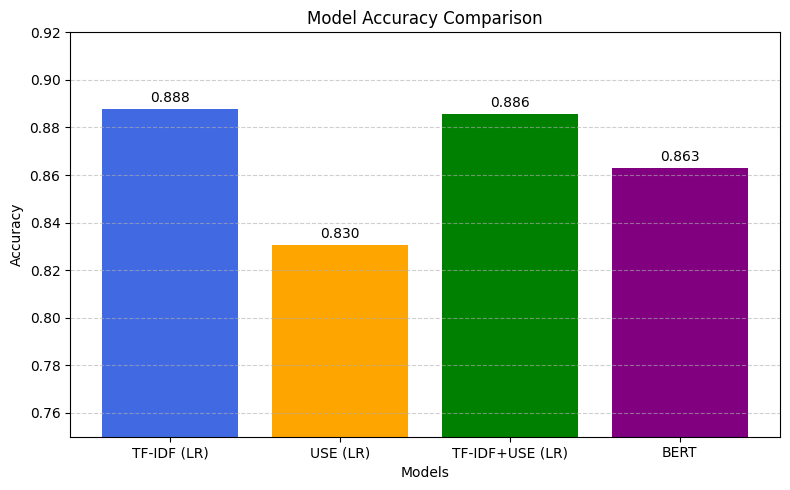

In [20]:
import matplotlib.pyplot as plt

models = [
    "TF-IDF (LR)",
    "USE (LR)",
    "TF-IDF+USE (LR)",
    "BERT"
]

accuracies = [
    0.8877,
    0.8304,
    0.8858,
    0.863
]

# Custom colors (clean + professional)
colors = ['royalblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies, color=colors)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.ylim(0.75, 0.92)

# Add values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.003, f"{v:.3f}", ha='center', fontsize=10)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

# Optional: Save image for GitHub
plt.savefig("accuracy_comparison.png")

plt.show()

In [31]:
model_dict = {
    "LinearSVM": LinearSVC(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": MultinomialNB(),
    "XGBoost": XGBClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100)
}

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<Figure size 600x500 with 0 Axes>

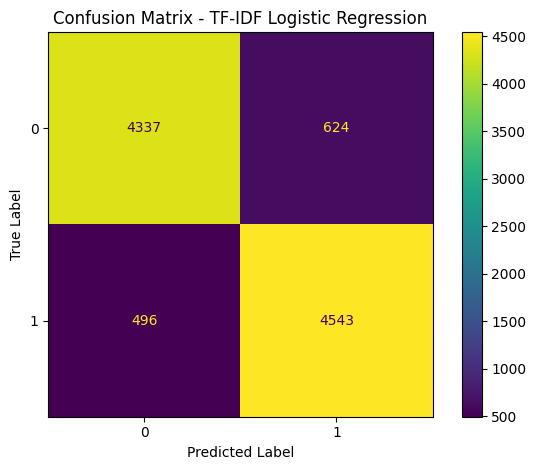

In [19]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('punkt')
nltk.download('stopwords')

# -------------------------------
# Load Data
# -------------------------------
df = pd.read_csv("IMDB Dataset.csv")

# -------------------------------
# Preprocessing
# -------------------------------
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['review'] = df['review'].apply(preprocess_text)

# -------------------------------
# Label Encoding
# -------------------------------
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], y, test_size=0.2, random_state=42
)

# -------------------------------
# TF-IDF Vectorization
# -------------------------------
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# -------------------------------
# Model Training
# -------------------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# -------------------------------
# Prediction
# -------------------------------
y_pred = lr.predict(X_test_tfidf)

# -------------------------------
# Confusion Matrix (Styled)
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(
    cmap='viridis',          # 🔥 Modern color theme
    values_format='d',       # Show integer values
    colorbar=True
)

plt.title("Confusion Matrix - TF-IDF Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.tight_layout()

# Optional: Save for GitHub
plt.savefig("confusion_matrix.png")

plt.show()

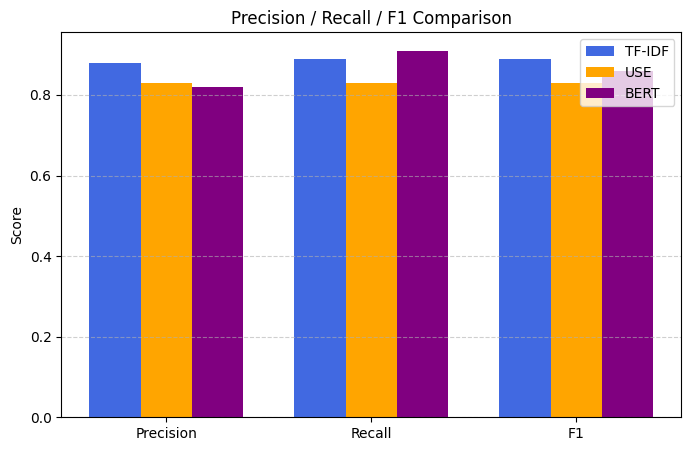

In [18]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision", "Recall", "F1"]

tfidf_scores = [0.88, 0.89, 0.89]
use_scores = [0.83, 0.83, 0.83]
bert_scores = [0.82, 0.91, 0.86]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(8,5))

# Custom colors
plt.bar(x - width, tfidf_scores, width, label='TF-IDF', color='royalblue')
plt.bar(x, use_scores, width, label='USE', color='orange')
plt.bar(x + width, bert_scores, width, label='BERT', color='purple')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Precision / Recall / F1 Comparison")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)  # 🔥 makes it look better

plt.show()

In [16]:
import pandas as pd

data = {
    "Model": ["TF-IDF (LR)", "USE (LR)", "TF-IDF+USE (LR)", "BERT"],
    "Accuracy": [0.888, 0.830, 0.886, 0.863],
    "Precision": [0.88, 0.83, 0.88, 0.83],
    "Recall": [0.89, 0.83, 0.89, 0.91],
    "F1 Score": [0.89, 0.83, 0.88, 0.86]
}

df = pd.DataFrame(data)
df

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF (LR),0.888,0.88,0.89,0.89
1,USE (LR),0.830,0.83,0.83,0.83
2,TF-IDF+USE (LR),0.886,0.88,0.89,0.88
3,BERT,0.863,0.83,0.91,0.86


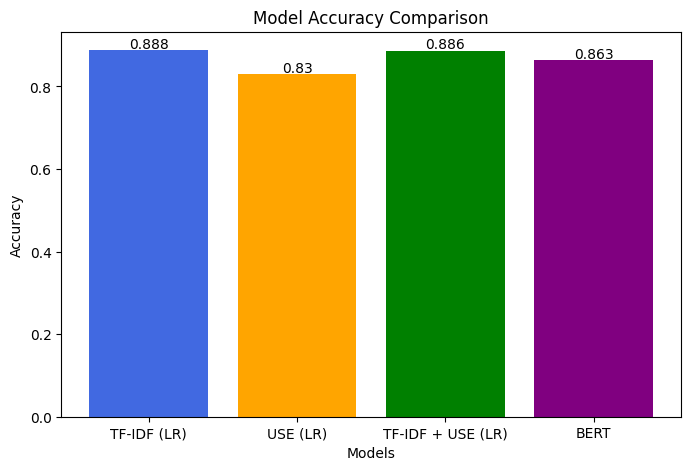

In [17]:
import matplotlib.pyplot as plt

models = ['TF-IDF (LR)', 'USE (LR)', 'TF-IDF + USE (LR)', 'BERT']
accuracy = [0.888, 0.830, 0.886, 0.863]

# Custom colors
colors = ['royalblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8,5))
plt.bar(models, accuracy, color=colors)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, str(round(v, 3)), ha='center')

plt.show()